In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel, t, norm, stats, nbinom
from scipy import stats

In [17]:
df_raw = pd.read_csv('diabetic_data.csv')
df_raw = df_raw[['diag_1']]
df_raw

,diag_1
0,250.83
1,276
2,648
3,8
4,197
...,...
101761,250.13
101762,560
101763,38
101764,996


In [18]:
def map_icd9(code):

    if pd.isna(code):
        return 'Missing'

    code = str(code).strip()

    if code.startswith('V'):
        return 'Supplementary_Factors'

    if code.startswith('E'):
        return 'External_Causes'

    try:
        num = float(code)
    except ValueError:
        return 'Unknown'

    if 1 <= num <= 139:
        return 'Infectious_Parasitic'

    elif 140 <= num <= 239:
        return 'Neoplasms'

    elif 240 <= num <= 279:
        return 'Endocrine_Metabolic_Immunity'

    elif 280 <= num <= 289:
        return 'Blood_Diseases'

    elif 290 <= num <= 319:
        return 'Mental_Disorders'

    elif 320 <= num <= 389:
        return 'Nervous_Sense_Organs'

    elif 390 <= num <= 459:
        return 'Circulatory'

    elif 460 <= num <= 519:
        return 'Respiratory'

    elif 520 <= num <= 579:
        return 'Digestive'

    elif 580 <= num <= 629:
        return 'Genitourinary'

    elif 630 <= num <= 679:
        return 'Pregnancy_Childbirth'

    elif 680 <= num <= 709:
        return 'Skin_Subcutaneous'

    elif 710 <= num <= 739:
        return 'Musculoskeletal'

    elif 740 <= num <= 759:
        return 'Congenital_Anomalies'

    elif 760 <= num <= 779:
        return 'Perinatal'

    elif 780 <= num <= 799:
        return 'Symptoms_IllDefined'

    elif 800 <= num <= 999:
        return 'Injury_Poisoning'

    else:
        return 'Unknown'


df_raw['diag_1'] = df_raw['diag_1'].apply(map_icd9)
df_raw

,diag_1
0,Endocrine_Metabolic_Immunity
1,Endocrine_Metabolic_Immunity
2,Pregnancy_Childbirth
3,Infectious_Parasitic
4,Neoplasms
...,...
101761,Endocrine_Metabolic_Immunity
101762,Digestive
101763,Infectious_Parasitic
101764,Injury_Poisoning


In [19]:
df = pd.read_csv('diabetic_encoded.csv')
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Musculoskeletal,diag_Mental_Disorders,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,0,0,1,0
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,0,1,0,1,0,0,0,0,0,0
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,0,0,1,1,0,0
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,0,1,0,0,0,1,0,0,0,0
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [20]:
df = df.join(df_raw)
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Mental_Disorders,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases,diag_1
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,0,1,0,Pregnancy_Childbirth
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,0,1,0,0,0,0,0,0,Infectious_Parasitic
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,0,Neoplasms
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,1,0,1,0,0,0,0,0,0,Endocrine_Metabolic_Immunity
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,0,1,1,0,0,Digestive
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,1,0,0,0,1,0,0,0,0,Infectious_Parasitic
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,0,1,Injury_Poisoning


я посмотрела на pairplot из EDA (тут он отказался рисоваться, поэтому нарисовала там). я сделала цвета по readmittion. 

можно заметить, что в колонке num_inpatient все значения левее - без повторной госпитализации, а значения правее - с ней (причем и >30 дней и меньше). отсюда вытекает первая гипотеза - мы хотим проверить, связано ли количество прошлых госпитализаций с фактом повторной госпитализации сейчас.

итак:

нулевая гипотеза H<sub>0</sub>: распределение number_inpatient в выборках людей с и без повторной госпитализации одинаково.

альтернативная гипотеза H<sub>1</sub>: распределение number_inpatient в выборке людей с повторной госпитализацией больше, чем в группе без.

посмотрим на сами распределения

In [33]:
df_n = df[df['readmitted'] == 0][['number_inpatient', 'readmitted']]
df_n

,number_inpatient,readmitted
0,0,0
2,1,0
3,0,0
4,0,0
6,0,0
...,...,...
101759,0,0
101762,1,0
101763,0,0
101764,1,0


In [34]:
df_y = df[df['readmitted'] > 0][['number_inpatient', 'readmitted']]
df_y

,number_inpatient,readmitted
1,0,1
5,0,1
7,0,1
10,0,1
11,0,2
...,...,...
101754,0,1
101755,0,1
101756,1,1
101760,2,1


в группе без повторной госпитализации 54864 объекта, в группе с - 46902. для такого большого числа объектов можно сказать, что это примерно равное распределение групп и дисбаланса особо нет. 

In [42]:
df['re_bin'] = (df['readmitted'] > 0).astype(int)
df

,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_Skin_Subcutaneous,diag_Circulatory,diag_External_Causes,diag_Genitourinary,diag_Digestive,diag_Symptoms_IllDefined,diag_Supplementary_Factors,diag_Blood_Diseases,diag_1,re_bin
0,8222157,0.0,0,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,0
1,55629189,0.0,1,3,59,0,18,0,0,0,...,0,0,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,1
2,86047875,0.0,2,2,11,5,13,2,0,1,...,0,0,0,0,0,0,1,0,Pregnancy_Childbirth,0
3,82442376,1.0,3,2,44,1,16,0,0,0,...,0,1,0,0,0,0,0,0,Infectious_Parasitic,0
4,42519267,1.0,4,1,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,Neoplasms,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,1.0,7,3,51,0,16,0,0,0,...,0,1,0,0,0,0,0,0,Endocrine_Metabolic_Immunity,1
101762,74694222,0.0,8,5,33,3,18,0,0,1,...,0,0,0,0,1,1,0,0,Digestive,0
101763,41088789,1.0,7,1,53,0,9,1,0,0,...,0,0,0,1,0,0,0,0,Infectious_Parasitic,0
101764,31693671,0.0,8,10,45,2,21,0,0,1,...,0,0,0,0,0,0,0,1,Injury_Poisoning,0


<Axes: xlabel='number_inpatient', ylabel='Count'>

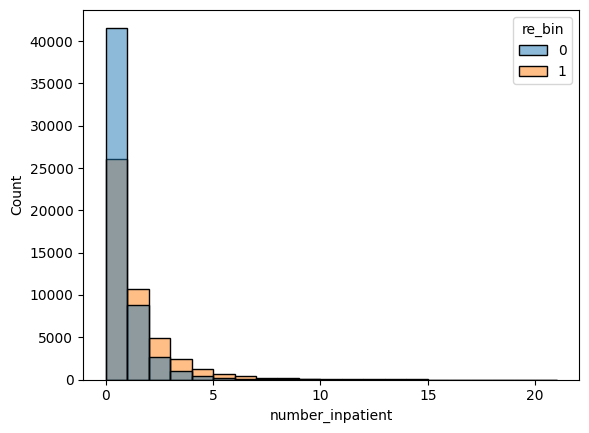

In [43]:
sns.histplot(df, x='number_inpatient', hue='re_bin', binwidth=1)

мы хотим сравнивать распределения двух групп, поэтому нам нужен подходящий тест для этого. одним из вариантов является т-тест. для него требуется нормальность распределения данных. по гистограмме выше видно, что данные точно не распределены нормально, но можно так же проверить это с помощью теста Шапиро. однако тест Шапиро довольно плохо работает с большими объемами данных, тк чувствителен даже к небольшим отклонениям, так что его мы проведем на подвыборках

тут у нас будет нулевая гипотеза H<sub>0</sub>: распеределение данных нормальное

альтернативная гипотеза H<sub>1</sub>: данные имеют распределение, отличное от нормального

уровень значимости 0.05

In [44]:
from scipy.stats import shapiro

In [96]:
for i in range(1, 100, 10):
    y = df_y['number_inpatient'].sample(500, random_state=i)
    n = df_n['number_inpatient'].sample(500, random_state=i)
    print(f'тест на y (с readmittion): {shapiro(y)}')
    print(f'тест на n (без readmittion): {shapiro(n)}')

тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6747480636720824), pvalue=np.float64(7.664955545765886e-30))
тест на n (без readmittion): ShapiroResult(statistic=np.float64(0.5039584049790057), pvalue=np.float64(4.478608261408774e-35))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6300601590504487), pvalue=np.float64(2.163888522148203e-31))
тест на n (без readmittion): ShapiroResult(statistic=np.float64(0.537829043061048), pvalue=np.float64(3.6230180361318415e-34))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6294399747068073), pvalue=np.float64(2.064453567979597e-31))
тест на n (без readmittion): ShapiroResult(statistic=np.float64(0.42524839337681897), pvalue=np.float64(5.2533223182757895e-37))
тест на y (с readmittion): ShapiroResult(statistic=np.float64(0.6758260255195601), pvalue=np.float64(8.392932113510432e-30))
тест на n (без readmittion): ShapiroResult(statistic=np.float64(0.5142086644295305), pvalue=np.float64(8.327108804214

{'whiskers': [<matplotlib.lines.Line2D at 0x26b747fa3c0>,
 'caps': [<matplotlib.lines.Line2D at 0x26b747fa660>,
 'boxes': [<matplotlib.lines.Line2D at 0x26b747fa270>],
 'medians': [<matplotlib.lines.Line2D at 0x26b747fa900>],
 'fliers': [<matplotlib.lines.Line2D at 0x26b747faa50>],
 'means': []}

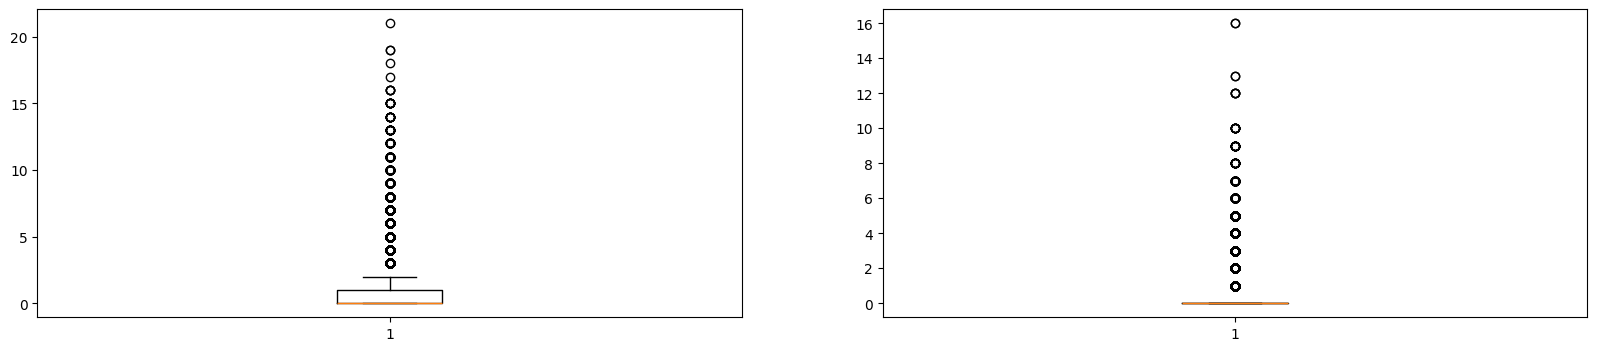

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
axes[0].boxplot(df_y['number_inpatient'])
axes[1].boxplot(df_n['number_inpatient'])

посмотрела на boxplot и кроме того, что ещё раз убедилась, что данные в обеих выборках не распределены нормально, показала визуально предположение, что в df_y распределение больше. это видно, тк у него явно шире сам ящик, длиннее ус (один, тк второй всё ещё в точке 0 вместе с левой (нижней) границей боксплота) и больше выбросов на высоких значениях

итак, мы имеем данные, которые распределены не нормально. т-тест на таких данных работает некорректно, так что будем использовать его аналог - тест U-критерий Манна-Уитни. 

его корректно использовать, тк выборки независимы, данные не нормально распределены, данные числовые

только U-критерий не сравнивает сразу медианы, он определяет сдвиг распределений относительно друг друга. так что сформулирую гипотезы таким образом. (это из моего дз если что)

нулевая гипотеза H<sub>0</sub>: распеределения не сдвинуты относительно друг друга

альтернативная гипотеза H<sub>1</sub>: распределение df_y['number_inpatient'] больше df_n['number_inpatient']

уровень значимости возьмем 0.01, тк выборка очень большая

In [46]:
from scipy.stats import mannwhitneyu

In [50]:
mannwhitneyu(df_y['number_inpatient'], df_n['number_inpatient'], alternative='greater')

MannwhitneyuResult(statistic=np.float64(1572533986.0), pvalue=np.float64(0.0))

значение p-value получилось очень маленькое: p-value < 0.01, значит отвергаем нулевую гипотезу и принимаем альтернативную о том, что распределения сдвинуты относительно друг друга. и, в соответствии с нашими изначальными формулировками - распределение number_inpatient в выборке людей с повторной госпитализацией юольше, чем в группе без.

также мы убедились в этом с помощью сравнения boxplot для двух выборок.

итак, мы посмотрели на гипотезы с бинарным значением readmittion. но у нас оно тернарное, а это позволяет сделать ещё один интересный тест - тест Краскала-Уоллиса.

для теста Краскала-Уоллиса определим гипотезы иначе:

нулевая гипотеза H<sub>0</sub>: распределение number_inpatient во всех выборках людей одинаково (без повторной госпитализации, <30 дней, >30 дней).

альтернативная гипотеза H<sub>1</sub>: распределение number_inpatient хотя бы в одной выборке из трех отличается.

уровень значимости 0.01, так как выборки большие

этот тест мы можем использовать, тк у нас независимые выборки, данные распределены не нормально, 3 группы для сравнения, данные числовые

In [58]:
df_n = df[df['readmitted'] == 0][['number_inpatient', 'readmitted']]
df_l30 = df[df['readmitted'] == 1][['number_inpatient', 'readmitted']]
df_g30 = df[df['readmitted'] == 2][['number_inpatient', 'readmitted']]

посмотрим на распределения тоже

<Axes: xlabel='number_inpatient', ylabel='Count'>

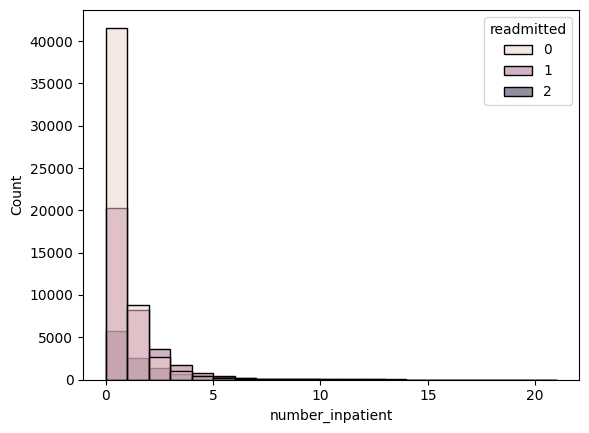

In [60]:
sns.histplot(df, x='number_inpatient', hue='readmitted', binwidth=1)

(array([9.548e+03, 1.075e+03, 4.210e+02, 1.620e+02, 7.300e+01, 5.000e+01,
        1.400e+01, 1.100e+01, 1.000e+00, 2.000e+00]),
 array([ 0. ,  2.1,  4.2,  6.3,  8.4, 10.5, 12.6, 14.7, 16.8, 18.9, 21. ]),
 <BarContainer object of 10 artists>)

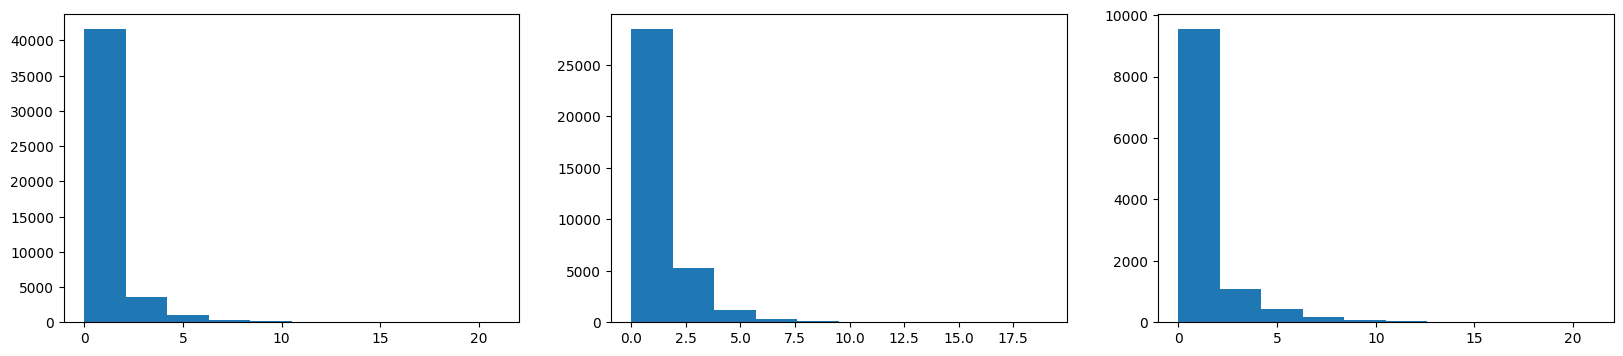

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
axes[0].hist(df_y['number_inpatient'])
axes[1].hist(df_l30['number_inpatient'])
axes[2].hist(df_g30['number_inpatient'])

{'whiskers': [<matplotlib.lines.Line2D at 0x26b75fe3e00>,
 'caps': [<matplotlib.lines.Line2D at 0x26b760701a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x26b75fe3cb0>],
 'medians': [<matplotlib.lines.Line2D at 0x26b76070440>],
 'fliers': [<matplotlib.lines.Line2D at 0x26b76070590>],
 'means': []}

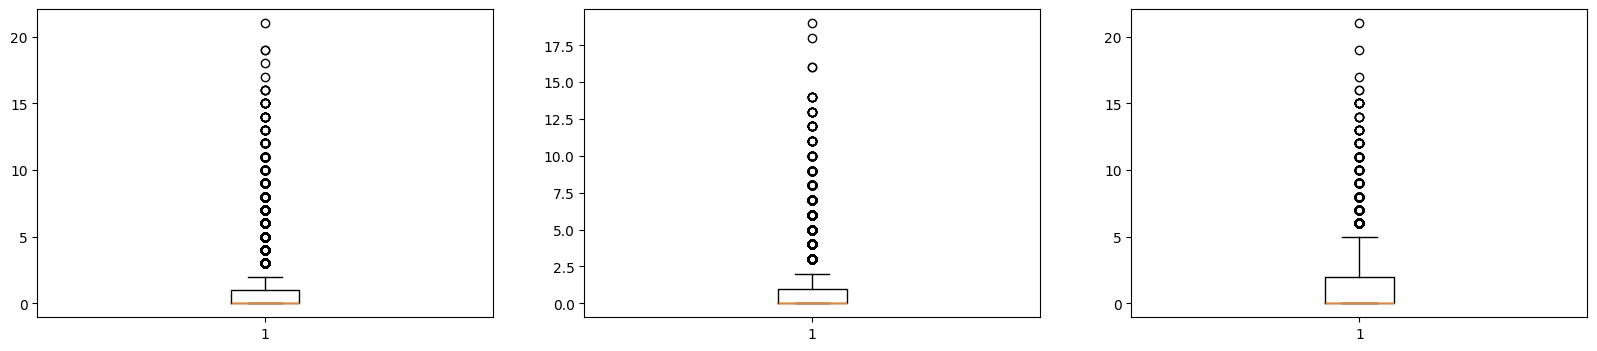

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
axes[0].boxplot(df_y['number_inpatient'])
axes[1].boxplot(df_l30['number_inpatient'])
axes[2].boxplot(df_g30['number_inpatient'])

https://blog.skillfactory.ru/glossary/kriterij-kraskela-uollisa/ вот тут ещё увидела, что данные должны быть распределены похожим образом в выборках. это как раз так: мы видим на гистограммах и боксплотах, что данные распределены схоже. на боксплотах также видно, что у третьей выборки (с госпитализацией позже 30 дней) ящик с ус больше, что визуально показывает, что у этой выборки смещено распределение number_inpatient. впрочем, сейчас мы проверим это тестом

In [62]:
from scipy.stats import kruskal

In [65]:
kruskal(df_n['number_inpatient'], df_l30['number_inpatient'], df_g30['number_inpatient'])

KruskalResult(statistic=np.float64(5662.510561648792), pvalue=np.float64(0.0))

итак, p-value < 0.01, значит мы отвергаем нулевую гипотезу и принимаем альтернативную о том, что распределение number_inpatient хотя бы в одной выборке отличается.

https://en.wikipedia.org/wiki/Kruskal%E2%80%93Wallis_test вот тут я узнала, что дальше, чтобы сравнить выборки попарно, можно использовать Dunn's test (For analyzing the specific sample pairs for stochastic dominance, Dunn's test,[4] pairwise Mann–Whitney tests with Bonferroni correction,[5] or the more powerful but less well known Conover–Iman test[5] are sometimes used.) сделаю его

используем Дунн-тест

https://www.geeksforgeeks.org/machine-learning/how-to-perform-dunns-test-in-python/ тут про него почитала

сформулируем новые гипотезы для этой проверки:

нулевая гипотеза H<sub>0</sub> для каждой пары выборок: распределение number_inpatient одинаково

альтернативная гипотеза H<sub>1</sub> для каждой пары выборок: распределение number_inpatient различается.

уровень значимости 0.01, так как выборки большие

In [71]:
! pip install scikit-posthocs

In [70]:
import scikit_posthocs as sp
sp.posthoc_dunn([df_n['number_inpatient'], df_l30['number_inpatient'], df_g30['number_inpatient']], p_adjust='bonferroni')


,1,2,3
1,1.0,0.000000e+00,0.000000e+00
2,0.0,1.000000e+00,2.001093e-67
3,0.0,2.001093e-67,1.000000e+00


итак, мы видим таблицу значений p-value для выборок попарно

каждая выборка, очевидно, не различается сама с собой (p-value = 1 > 0.01), но формально мы не имеем оснований отвергнуть нулевую гипотезу

выборка 1-2 (нет повторной госпитализации и повт. госпитализация в течение 30 дней): p-value < 0.01, значит что мы отверагаем нулевую гипотезу и принимаем альтернативную о том, что распределение number_inpatient в этих двух выборках различаются

выборка 1-3 (нет повторной госпитализации и повт. госпитализация в течение больше 30 дней): p-value < 0.01, значит что мы отверагаем нулевую гипотезу и принимаем альтернативную о том, что распределение number_inpatient в этих двух выборках различаются

выборка 2-3 (повт. госпитализация в течение 30 дней и повт. госпитализация в течение больше 30 дней): p-value < 0.01, значит что мы отверагаем нулевую гипотезу и принимаем альтернативную о том, что распределение number_inpatient в этих двух выборках различаются

итого, мы можем сказать. что распределение number_inpatient статистически значимо различается во всех трех выборках.

а ещё, чтобы проверить другим способом, сделаю the more powerful but less well known Conover–Iman тест (пон да отсылка на ту цитату с википедии)

гипотезы оставим такие же:

нулевая гипотеза H<sub>0</sub> для каждой пары выборок: распределение number_inpatient одинаково

альтернативная гипотеза H<sub>1</sub> для каждой пары выборок: распределение number_inpatient различается.

уровень значимости 0.01, так как выборки большие

In [72]:
sp.posthoc_conover([df_n['number_inpatient'], df_l30['number_inpatient'], df_g30['number_inpatient']], p_adjust='holm')

,1,2,3
1,1.0,0.000000e+00,0.000000e+00
2,0.0,1.000000e+00,1.107775e-71
3,0.0,1.107775e-71,1.000000e+00


результаты p-value немного отличаются, но результат такой же: распределение number_inpatient статистически значимо различается во всех трех выборках.


про варианты поправок https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html, https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%BF%D1%80%D0%B0%D0%B2%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BC%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%83%D1%8E_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D1%83_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7 

и ещё вариант pairwise Mann–Whitney tests with Bonferroni correction тоже из той же статьи

гипотезы оставим такие же:

нулевая гипотеза H<sub>0</sub> для каждой пары выборок: распределение number_inpatient одинаково

альтернативная гипотеза H<sub>1</sub> для каждой пары выборок: распределение number_inpatient различается.

уровень значимости 0.01, так как выборки большие

In [120]:
from statsmodels.stats.multitest import multipletests

In [ ]:
pairs = [
    (df_n['number_inpatient'], df_l30['number_inpatient']),
    (df_n['number_inpatient'], df_g30['number_inpatient']),
    (df_l30['number_inpatient'], df_g30['number_inpatient'])
]

p_values = []

for g1, g2 in pairs:
    p_values.append(mannwhitneyu(g1, g2)[1])

corrected = multipletests(p_values, method='bonferroni')

print(f'corrected p на выборках df_n и df_l30 = {corrected[1][0]}')
print(f'corrected p на выборках df_n и df_g30 = {corrected[1][1]}')
print(f'corrected p на выборках df_l30 и df_g30 = {corrected[1][2]}')

corrected p на выборках df_n и df_l30 = 0.0
corrected p на выборках df_n и df_g30 = 0.0
corrected p на выборках df_l30 и df_g30 = 7.80602993522616e-65


итого, p-value на всех трех группах < 0.01, значит отвергаем нулевую гипотезу и принимаем альтернативную о том, что во всех выборках распределение number_inpatient различается статистически значимо.

итак, все три варианта теста показали статистически значимые различия распределений между всеми парами выборок.

я использовала Dunn test с поправкой Bonferroni, Conover-Iman test с поправкой Holm и pairwise Mann–Whitney tests тоже с поправкой Bonferroni. вообще, Dunn test считается самым классическим продолжением теста Краскала–Уоллиса, однако поправка Bonferroni делает критерий более строгим и снижает вероятность случайного отвержения нулевой гипотезы. тест Conover-Iman дал несколько меньшие значения p-value, что связано с его большей чувствительностью и в целом он считается более мощным и лучше ищет различия между группами, особенно на больших выборках. pairwise Mann–Whitney тесты это прямые попарные сравнения, но они требуют дополнительной коррекции уровня значимости из-за множественных проверок гипотез, потому что иначе появляется вероятность ошибочного роста значимости.

тем не менее, все три теста показали одинаковый результат, несмотря на разные подходы. это говорит о надежности результатов и показывает, что итоговый вывод не зависит от выбора теста.

погнали вторую гипотезу

по pairplot видно, что возможно есть корреляция между time_in_hospital и num_medications. для нас это важно, чтобы заранее можно было более точно оцениать стоимость лечения и затраты на содержание пациента в больнице.

посмотрим более подробно на них

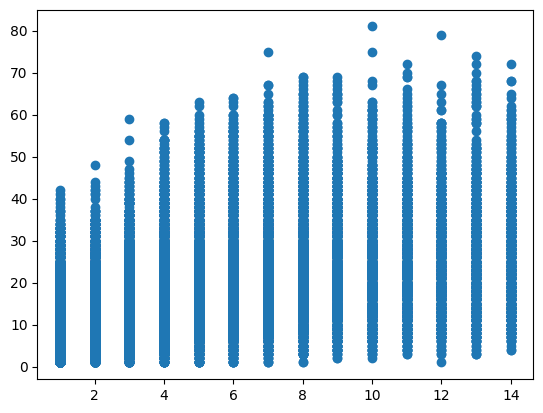

In [74]:
plt.scatter(df['time_in_hospital'], df['num_medications'])

визуально видно, что с ростом дней госпитализации растет и количество медикаментов

проверим это с помощью статистических тестов

для начала сформулируем гипотезы:

нулевая гипотеза H<sub>0</sub>: корреляции между time_in_hospital и num_medications нет или она незначительна, статистически значимой связи нет.

альтернативная гипотеза H<sub>1</sub>: статисически значимая связь между time_in_hospital и num_medications есть.

уровень значимости 0.01, так как выборки большие

для начала нужно проверить данные на нормальность

только единственное, у нас есть люди, умершие в больнице и рассматривать их некорректно, так что я их удалю

In [92]:
df_1 = df[(df['discharge_disposition_id_11'] == 0) & (df['discharge_disposition_id_19'] == 0) & (df['discharge_disposition_id_20'] == 0)]

(array([1.5344e+04, 4.4570e+04, 2.7339e+04, 9.0990e+03, 2.4430e+03,
        7.8600e+02, 3.4800e+02, 1.4100e+02, 3.9000e+01, 5.0000e+00]),
 array([ 1.,  9., 17., 25., 33., 41., 49., 57., 65., 73., 81.]),
 <BarContainer object of 10 artists>)

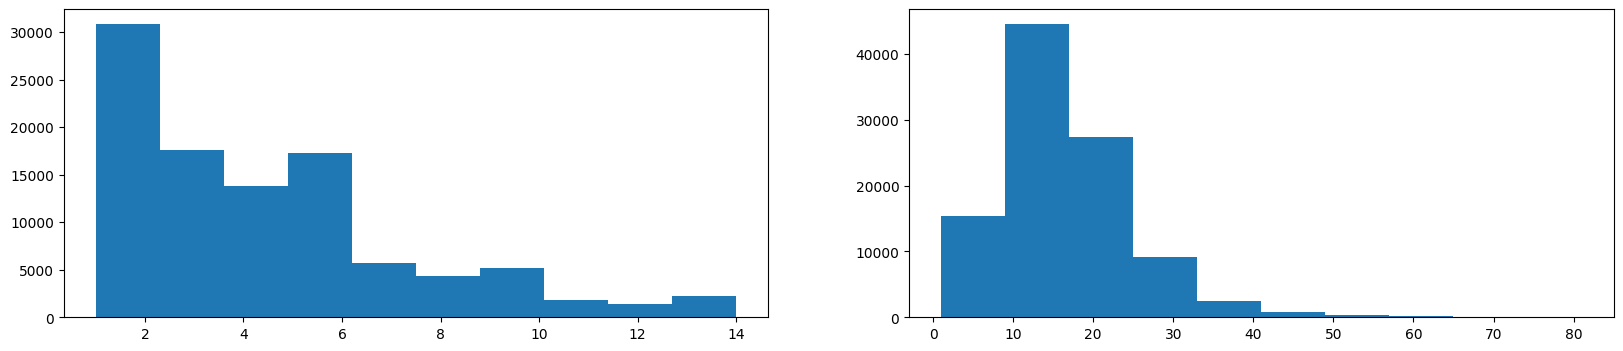

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
axes[0].hist(df_1['time_in_hospital'])
axes[1].hist(df_1['num_medications'])

In [78]:
from statsmodels.api import qqplot

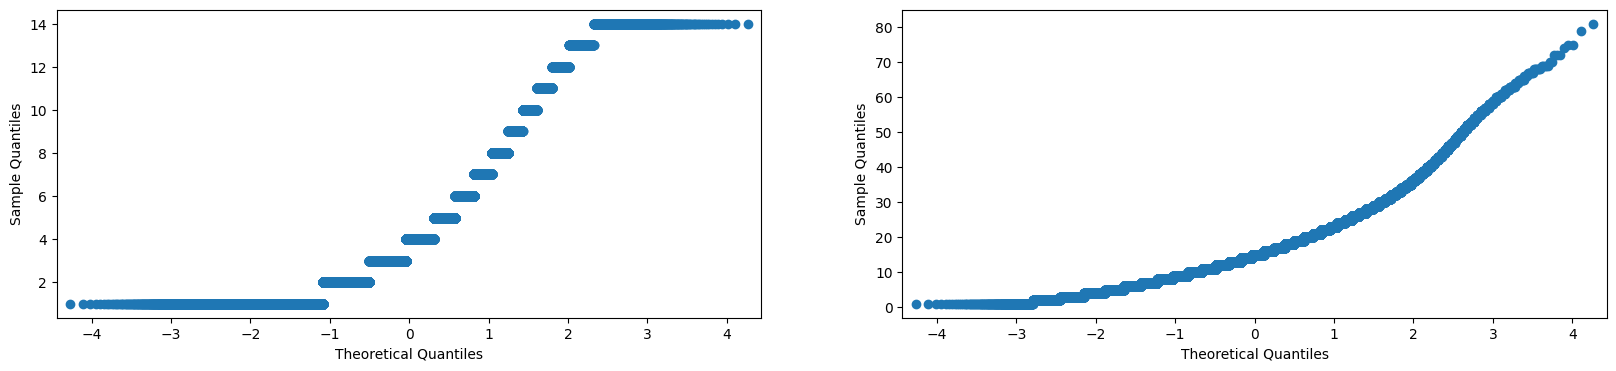

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
qqplot(df_1['time_in_hospital'], ax=axes[0])
qqplot(df_1['num_medications'], ax=axes[1])
plt.show()

проведем тест шапиро на подвыборках, как мы делали для 1 гипотезы. для начала сформулируем гипотезы:

нулевая гипотеза H<sub>0</sub>: распеределение данных нормальное

альтернативная гипотеза H<sub>1</sub>: данные имеют распределение, отличное от нормального

уровень значимости 0.05

In [98]:
for i in range(1, 100, 10):
    d1 = df_1['time_in_hospital'].sample(500, random_state=i)
    d2 = df_1['num_medications'].sample(500, random_state=i)
    print(f'тест на time_in_hospital: {shapiro(d1)}')
    print(f'тест на num_medications: {shapiro(d2)}')

тест на time_in_hospital: ShapiroResult(statistic=np.float64(0.8748344506547296), pvalue=np.float64(1.227709530582988e-19))
тест на num_medications: ShapiroResult(statistic=np.float64(0.9261564098652191), pvalue=np.float64(5.71361136093905e-15))
тест на time_in_hospital: ShapiroResult(statistic=np.float64(0.8968968875899447), pvalue=np.float64(7.664975139326818e-18))
тест на num_medications: ShapiroResult(statistic=np.float64(0.9273299251859429), pvalue=np.float64(7.723949936214935e-15))
тест на time_in_hospital: ShapiroResult(statistic=np.float64(0.867907333938414), pvalue=np.float64(3.7479208404622997e-20))
тест на num_medications: ShapiroResult(statistic=np.float64(0.9127666915593229), pvalue=np.float64(2.276934090271524e-16))
тест на time_in_hospital: ShapiroResult(statistic=np.float64(0.8886727080420166), pvalue=np.float64(1.5313198169399e-18))
тест на num_medications: ShapiroResult(statistic=np.float64(0.9085627951842457), pvalue=np.float64(8.904450037475272e-17))
тест на time_in

итак, я посмотрела несколько способов проверки данных на нормальность: визуальные и с помощью теста шапиро. на всех подвыборках для обоих распределений тест шапиро дал p-value < 0.05, что позволяет отвергнуть нулевую гипотезу и принять альтернативную о том, что данные распределены не нормально.

итак, мы выяснили, что данные не распределены нормально, так что использовать корреляцию спирмена будет более точно, так как он работает с ранговыми значениями и устойчив к выбросам и ненормальному распределению. однако я проведу оба теста, чтобы сравнить их значения.

In [99]:
from scipy.stats import pearsonr, spearmanr

In [100]:
spearmanr(df_1['time_in_hospital'], df_1['num_medications'])

SignificanceResult(statistic=np.float64(0.46379268908480736), pvalue=np.float64(0.0))

In [ ]:
pearsonr(df_1['time_in_hospital'], df_1['num_medications'])

PearsonRResult(statistic=np.float64(0.464081735546386), pvalue=np.float64(0.0))

p-value < 0.01, значит можем отвергнуть нулевую гипотезу и принять альтернативную о том, что статисически значимая связь между time_in_hospital и num_medications есть. в обоих тестах. это не то, что я ожидала увидеть. из-за того, что данных очень много, p-value очень близко к 0 в обоих тестах. 

но мы можем посмоттреть не только на p-value, но и на саму статистику (https://webask.io/glossary/effect-size). таким образом, мы можем увидеть, что для корелляции спирмена коэф = 0.4638, а для корелляции пирсона = 0.4641. сравнивая с порогами Коэна, это средний эффект. то есть различия не только статистически значимы, но и пркактическую значимость их.

получается, что несмотря на то, что распределения не нормальные, зависимость между распределениями близка к линейной, поэтому оба метода дают практически одинаковые результаты (пирсон показывает линейную связь)

погнали третью гипотезу

Из EDA мы заметили, что пациенты, которым был назначен инсулин возвращаются обратно в госпитализацию. мы хотим это проверить

Сформулируем гипотезы:

H0: Назначение инсулина `insulin` несвязано с последующей госпитализацией.

H1: Назначение инсулина `insulin` связано с последующей госпитализацией.

Уровень значимости возьмем 0,01, также из-за большого объема данных.

In [122]:
df['insulin']

0         0
1         3
2         0
3         3
4         1
         ..
101761    2
101762    1
101763    2
101764    3
101765    0
Name: insulin, Length: 101766, dtype: int64

In [123]:
df['readmitted']

0         0
1         1
2         0
3         0
4         0
         ..
101761    1
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64

In [124]:
res = pd.crosstab(df['insulin'], df['readmitted'])
print(res)

readmitted      0      1     2
insulin                       
0           26678  15949  4756
1           16934  10482  3433
2            5768   4752  1698
3            5484   4362  1470


Источник: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html

In [125]:
from scipy.stats import chi2_contingency
chi2_contingency(res)

Chi2ContingencyResult(statistic=np.float64(516.695760681305), pvalue=np.float64(2.1265863574275524e-108), dof=6, expected_freq=array([[25545.08295501, 16550.01410098,  5287.90294401],
       [16631.2868345 , 10774.99071399,  3442.72245151],
       [ 6586.95784447,  4267.52363265,  1363.51852289],
       [ 6100.67236602,  3952.47155238,  1262.8560816 ]]))

https://habr.com/ru/companies/mygames/articles/677074/$0

Значения p_value < 0.01, поэтому отвергаем H0, и принимаем альтернативную гипотезу H1 о том, что у нас есть связь между выдачей инсулина и будущей госпитализацией.

In [128]:
n = res.sum().sum()
np.sqrt(chi2_contingency(res)[0] / (n * (min(res.shape[0]-1, res.shape[1]-1))))

np.float64(0.050384980992150365)